# Notebook 2: quantitative analysis pipeline

## GitHub rerun note

This notebook was run with the required CSV files available in the working directory. In the GitHub repository, these files are stored in `data/raw/`, so paths may need adjusting if rerunning from a fresh clone.

This notebook also creates `clean_df.csv`. That file is not included in the repository because it is too large for standard GitHub upload. To recreate it, run this notebook after placing the raw CSV files in the right location.


### Notebook 2: quantitative NLP pipeline

In this notebook I test whether manosphere language changes across eras, and whether older detection methods transfer poorly to newer Sigma-era language.

It should be run from top to bottom once the project CSVs are in the working directory.


## Research questions and hypotheses

This notebook is the quantitative part of the project. I use it to check two things: first, whether the surface language changes from the Legacy era (2016 and earlier) to the Sigma era (2022-2025), and second, whether that change makes older detection methods less reliable.

**Research questions**

RQ1: Has the surface vocabulary of manosphere discourse changed between the Legacy and Sigma eras, compared with ordinary Reddit vocabulary drift in the control corpus?

RQ2: Does the underlying ideological content remain visible across eras, even when surface vocabulary and tone change, and can a classifier trained on one era still detect the other?

**Hypotheses**

H1: Sigma-era titles will show high lexical turnover from the Legacy era, but this alone will not exceed control-corpus turnover. This means vocabulary change cannot prove the argument on its own.

H2: SBERT scores will stay stable or rise across eras, VADER tone will stay fairly flat, and a classifier trained on Legacy data will perform worse on Sigma data. If that pattern holds, it suggests the language changes while the ideological signal does not disappear.


## Setup

In [1]:
# load the packages used across the notebook
!pip install nltk langdetect sentence-transformers vaderSentiment openpyxl scikit-learn scipy -q


[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [2]:
%matplotlib inline
import matplotlib
matplotlib.rcParams['backend'] = 'inline'

In [3]:
# core imports
import os
from pathlib import Path
import ast
import warnings
from collections import Counter

import pandas as pd
import numpy as np

warnings.filterwarnings('ignore')

In [4]:
# text processing imports
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from langdetect import detect, DetectorFactory
from langdetect.lang_detect_exception import LangDetectException

nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('vader_lexicon', quiet=True)

True

In [5]:
# modelling, statistics and plotting imports
from scipy.stats import kruskal

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.metrics.pairwise import cosine_similarity

from sentence_transformers import SentenceTransformer

import matplotlib.pyplot as plt

## 1. Preprocessing

Loading the master dataset from `Master_Manosphere_Dataset.csv`, built in Notebook 1 from HTML archives of four manosphere-adjacent subreddits. Analysis runs on post titles only. Lemmatisation is not applied.

In [6]:
# load master dataset built in notebook 1
master_df = pd.read_csv('Master_Manosphere_Dataset.csv')
len(master_df)
master_df['Subreddit'].value_counts()
master_df[['Year']].agg(['min','max']).T

,min,max
Year,2012,2025


### Ethics and anonymisation

The HTML archive files contain only post titles, timestamps, and subreddit labels. No author or username information is present. Analysis runs on aggregate lexical patterns across eras rather than individual user behaviour.

### Preprocessing

Three filters before tokenisation: posts shorter than 10 characters, non-English posts, and URL-containing posts.

Different analyses use different input text, and that's deliberate rather than an oversight. VADER scores the raw title to preserve punctuation, capitalisation, and negation - all of which the tokeniser would destroy and all of which matter for sentiment scoring. 

SBERT and TF-IDF use `joined_text` (cleaned, lowercased tokens) for semantic consistency with each other. The temporal classifier also uses raw titles since it's replicating what a moderation system would actually see. The practical implication is that the analyses aren't measuring exactly the same input, so preprocessing comparisons across methods should be read carefully.

In [7]:
# code adapted from notebook - data classification
# preprocessing function before tokenisation to clean data 
DetectorFactory.seed = 0

def detect_language(text):
    try:
        return detect(str(text))
    except LangDetectException:
        return 'unknown'

def clean_text_data(df):
    df = df.copy()
    df = df[df['Title'].notna()]
    df = df[df['Title'].str.len() > 10]
    df['lang'] = df['Title'].apply(detect_language)
    df = df[df['lang'] == 'en']
    df = df[~df['Title'].str.contains('http|www', case=False)]
    df = df[df['Year'] >= 2012]  # period of study 2012-2025
    return df

before = len(master_df)
clean_df = clean_text_data(master_df)
after = len(clean_df)
pd.Series({'rows before filtering': before, 'rows after filtering': after, 'rows dropped': before - after})

rows before filtering    19189
rows after filtering     17950
rows dropped              1239
dtype: int64

### Era labelling

Posts assigned to one of three eras based on year of publication. Boundaries follow Ging (2019) and Tanner & Gillardin (2025). Legacy (2012-2016) is the foundation era. Pill (2017-2021) is ideological crystallisation. Sigma (2022-2025) is the mutation era.

r/AllPillDebate only appears from 2020 and sits entirely within the Sigma bin.

In [8]:
# assign era labels based on year of publication
# bin_era maps publication year to era label
def bin_era(year):
    if year <= 2016: return 'Legacy'
    elif year <= 2021: return 'Pill'
    else: return 'Sigma'

clean_df['Era'] = clean_df['Year'].apply(bin_era)
clean_df['Era'].value_counts().sort_index()

Era
Legacy    6045
Pill      6565
Sigma     5340
Name: count, dtype: int64

In [9]:
# balance to equal era sizes for permutation test and temporal generalisation
# find the smallest era and sample that many from each
min_n = clean_df['Era'].value_counts().min()
balanced_df = (
    clean_df
    .groupby('Era')
    .sample(n=min_n, random_state=42)
    .reset_index(drop=True)
)
balanced_df['Era'].value_counts()

Era
Legacy    5340
Pill      5340
Sigma     5340
Name: count, dtype: int64

### Tokenisation

Titles are tokenised, lowercased, and stripped of stopwords and punctuation. I do not lemmatise the titles because mutated forms such as `looksmaxxing`, `redpill`, and `grindset` are part of the register signal rather than noise.


In [10]:
# code adapted from notebook - data classification
# initialise tokenisation, stopwords, and punctuation
# set up stopwords and punctuation for the vocabulary functions
stops = set(stopwords.words('english'))

def good_tokens(text):
    if pd.isna(text): return []
    words = word_tokenize(str(text))
    return [w.lower() for w in words if w.isalpha() and w.lower() not in stops]

clean_df['Clean_Tokens'] = clean_df['Title'].apply(good_tokens)
balanced_df['Clean_Tokens'] = balanced_df['Title'].apply(good_tokens)
clean_df['joined_text'] = clean_df['Clean_Tokens'].apply(lambda x: ' '.join(x))

clean_df[['Title', 'Clean_Tokens']].head(3)

,Title,Clean_Tokens
0,"Anecdotes, Sollipsism, and Hamsters. Does TRP'...","[anecdotes, sollipsism, hamsters, trp, narrati..."
1,I believe PPD to be a circlejerk and no longer...,"[believe, ppd, circlejerk, longer, successful,..."
2,Trp as projection,"[trp, projection]"


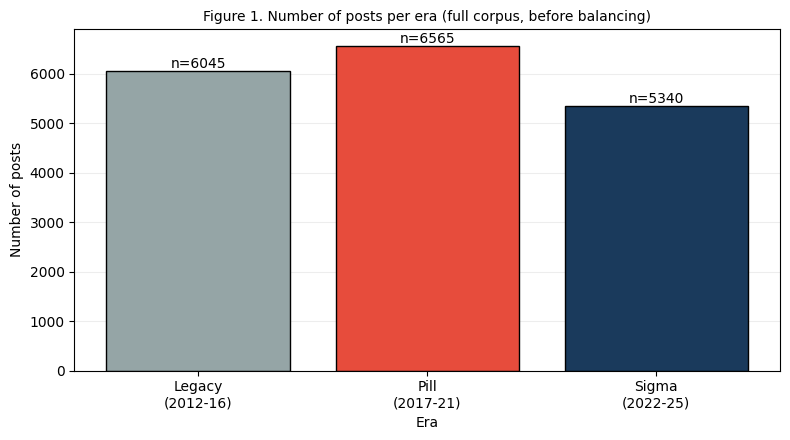

In [11]:
# era distribution: check corpus is roughly balanced before balancing
era_counts = clean_df['Era'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(['Legacy\n(2012-16)', 'Pill\n(2017-21)', 'Sigma\n(2022-25)'],
       era_counts.values, color=['#95a5a6', '#e74c3c', '#1A3A5C'], edgecolor='black')
for bar, n in zip(bars, era_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'n={n}',
            ha='center', va='bottom', fontsize=10)
ax.set_title('Figure 1. Number of posts per era (full corpus, before balancing)', fontsize=10)
ax.set_ylabel('Number of posts', fontsize=10)
ax.set_xlabel('Era', fontsize=10)
ax.tick_params(axis='both', labelsize=10)
ax.grid(axis='y', alpha=0.22)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

## 2.Has the surface vocabulary changed across eras?

Jaccard distance measures raw vocabulary turnover between eras. TF-IDF identifies the discriminating terms that characterise each era. Neither is an ideological measure on its own - that's what Section 6 is for.

### Jaccard distance

Jaccard distance is my first check for vocabulary change. It compares how much the vocabulary overlaps between two eras. A higher distance means the word sets are less similar.

This is useful as a surface-level check, but it cannot show whether the ideology has changed. It only shows vocabulary turnover. That is why I compare it with the control corpus and then move to SBERT for semantic similarity.


In [12]:
# jaccard distance - adapted from NLTK updated 
# each set is an era vocabulary, so the score measures vocabulary overlap between eras
results = {}

def get_vocab(df):
    tokens = df['Clean_Tokens'].explode().dropna()
    return set(w for w in tokens if isinstance(w, str) and len(w) > 2)

def jaccard_similarity(df_a, df_b):
    va = get_vocab(df_a)
    vb = get_vocab(df_b)
    return len(va & vb) / len(va | vb) if (va | vb) else 0

eras = {
    'Legacy': clean_df[clean_df['Era'] == 'Legacy'],
    'Pill':   clean_df[clean_df['Era'] == 'Pill'],
    'Sigma':  clean_df[clean_df['Era'] == 'Sigma']
}

for a, b in [('Legacy', 'Pill'), ('Pill', 'Sigma'), ('Legacy', 'Sigma')]:
    sim = jaccard_similarity(eras[a], eras[b])
    results[f'{a} to {b}'] = {'similarity': round(sim,4), 'turnover': round(1-sim,4)}
pd.DataFrame(results).T

,similarity,turnover
Legacy to Pill,0.4071,0.5929
Pill to Sigma,0.4033,0.5967
Legacy to Sigma,0.3725,0.6275


In [13]:
# permutation test on balanced corpus: legacy vs sigma
# running on balanced_df not clean_df to keep memory manageable
legacy_b = balanced_df[balanced_df['Era'] == 'Legacy']
sigma_b  = balanced_df[balanced_df['Era'] == 'Sigma']

In [14]:
# observed Legacy -> Sigma vocabulary overlap
v1 = get_vocab(legacy_b)
v2 = get_vocab(sigma_b)
obs_jaccard = len(v1 & v2) / len(v1 | v2)
obs_turnover = 1 - obs_jaccard

pd.Series({
    'observed Jaccard similarity': round(obs_jaccard, 4),
    'observed vocabulary turnover': round(obs_turnover, 4)
})

observed Jaccard similarity     0.3724
observed vocabulary turnover    0.6276
dtype: float64

In [15]:
# permutation baseline
# if era labels did not matter, shuffled legacy/sigma vocabularies should look closer to the observed score
np.random.seed(42)
n_perm = 500
perm_scores = []

all_tokens = balanced_df[['Era', 'Clean_Tokens']].copy()
all_eras = all_tokens['Era'].values.copy()

In [16]:
# build a simple null distribution by shuffling the era labels
for k in range(n_perm):
    shuffled_eras = np.random.permutation(all_eras)
    mask_leg = shuffled_eras == 'Legacy'
    mask_sig = shuffled_eras == 'Sigma'

    va = set(t for tokens in all_tokens['Clean_Tokens'][mask_leg] for t in tokens)
    vb = set(t for tokens in all_tokens['Clean_Tokens'][mask_sig] for t in tokens)
    combined = va | vb

    perm_scores.append(len(va & vb) / len(combined) if combined else 0)

perm_scores = np.array(perm_scores)

In [17]:
# p-value = share of shuffled scores as low as the observed score
# lower Jaccard means less vocabulary overlap
p_value = max((perm_scores <= obs_jaccard).mean(), 1/n_perm)

pd.Series({
    'observed jaccard': round(obs_jaccard, 4),
    'observed turnover': round(obs_turnover, 4),
    'null mean': round(perm_scores.mean(), 4),
    'p-value': round(p_value, 4)
})

observed jaccard     0.3724
observed turnover    0.6276
null mean            0.4305
p-value              0.0020
dtype: float64

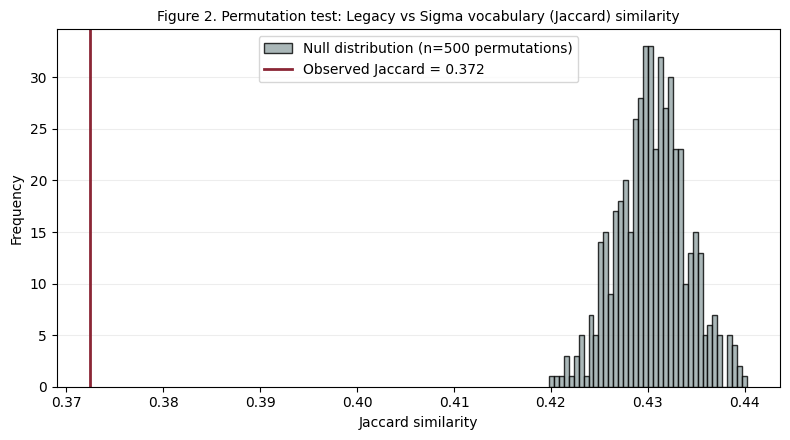

In [18]:
# plot the permutation check so the observed gap is easy to see
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(perm_scores, bins=40, color='#95a5a6', edgecolor='black', alpha=0.8,
        label=f'Null distribution (n={len(perm_scores)} permutations)')
ax.axvline(obs_jaccard, color='#8b2635', linewidth=2, label=f'Observed Jaccard = {obs_jaccard:.3f}')
ax.set_title('Figure 2. Permutation test: Legacy vs Sigma vocabulary (Jaccard) similarity', fontsize=10)
ax.set_xlabel('Jaccard similarity', fontsize=10)
ax.set_ylabel('Frequency', fontsize=10)
ax.tick_params(axis='both', labelsize=10)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.22)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

### Interpretation

The observed Legacy-to-Sigma similarity sits far away from the shuffled/null distribution. This suggests the two eras share less vocabulary than would be expected if the era labels were random.

For this project, the main point is that there is real surface-level vocabulary turnover. I do not treat this graph as proof of ideological change.


### Control corpus 

Comparing the Jaccard Distance result with a control comparison.

**Result:** control turnover = 0.813, manosphere turnover = 0.627, difference = -0.186. Control communities turn over more vocabulary than the manosphere for this sample.

The manosphere vocabulary changed, but the more important question is *how* it changed. That is why I use TF-IDF next, and why the classifier test later matters more for the detection argument.

In [19]:
# same jaccard distance method, used here as a control baseline
# this tests whether turnover is manosphere-specific or partly platform/time drift
ctrl_raw = pd.read_csv('comparison_v3.csv')
ctrl_posts = ctrl_raw[ctrl_raw['type'] == 'control'].copy()
ctrl_posts['Clean_Tokens'] = ctrl_posts['title'].apply(good_tokens)

In [20]:
# balance control eras before comparing turnover
# jaccard is sensitive to set size, so I keep the Legacy/Sigma comparison size-matched
ctrl_min = ctrl_posts['Era'].value_counts().min()
ctrl_bal = (
    ctrl_posts
    .groupby('Era')
    .sample(n=ctrl_min, random_state=42)
    .reset_index(drop=True)
)

ctrl_legacy = ctrl_bal[ctrl_bal['Era'] == 'Legacy']
ctrl_sigma  = ctrl_bal[ctrl_bal['Era'] == 'Sigma']

In [21]:
# calculate control vocabulary overlap 
ctrl_vocab_legacy = get_vocab(ctrl_legacy)
ctrl_vocab_sigma  = get_vocab(ctrl_sigma)
ctrl_similarity   = len(ctrl_vocab_legacy & ctrl_vocab_sigma) / len(ctrl_vocab_legacy | ctrl_vocab_sigma)
ctrl_turnover     = round(1 - ctrl_similarity, 4)

mano_turnover = round(1 - obs_jaccard, 4)

In [22]:
# if the control turnover is higher, jaccard alone cannot prove manosphere-specific mutation
pd.Series({
    'Manosphere Legacy-Sigma turnover': mano_turnover,
    'Control Legacy-Sigma turnover': ctrl_turnover,
    'Difference (mano - control)': round(mano_turnover - ctrl_turnover, 4)
})

Manosphere Legacy-Sigma turnover    0.6276
Control Legacy-Sigma turnover       0.7751
Difference (mano - control)        -0.1475
dtype: float64

### TF-IDF discriminating vocabulary

Which terms are most characteristic of each era relative to the others. This is the primary lexical evidence for register shift.

In [23]:
# tf-idf ranks terms that are distinctive to each era
# jaccard tells me vocabulary changed; TF-IDF helps show what kind of language replaced it
tfidf = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf.fit_transform(clean_df['joined_text'])
X_tfidf.shape

(17950, 5000)

In [24]:
# reset index so tfidf matrix rows align with clean_df rows
clean_df = clean_df.reset_index(drop=True)

In [25]:
# tf-idf ranks terms that separate one era from the others
# top discriminating terms per era: identifies vocabulary most characteristic of each era
# rows must align
assert X_tfidf.shape[0] == len(clean_df), 'tfidf/clean_df row mismatch - run cells 24-25 in order'

feature_names = tfidf.get_feature_names_out()

rows = {}
for era in ['Legacy', 'Pill', 'Sigma']:
    idx = clean_df[clean_df['Era'] == era].index
    era_tfidf = X_tfidf[idx].mean(axis=0).A1
    top_idx = era_tfidf.argsort()[::-1][:15]
    rows[era] = [feature_names[i] for i in top_idx]

tfidf_table = pd.DataFrame(rows, index=[f'Rank {i+1}' for i in range(15)])
tfidf_table

,Legacy,Pill,Sigma
Rank 1,women,women,women
Rank 2,trp,men,men
Rank 3,men,girl,dating
Rank 4,pill,sex,get
Rank 5,red,get,girls
Rank 6,fr,girls,sex
Rank 7,girl,want,want
Rank 8,game,dating,man
Rank 9,get,woman,woman
Rank 10,like,man,girl


In [26]:
# check which legacy markers actually dropped out of the sigma top terms
top_terms_legacy = rows['Legacy']
top_terms_sigma  = rows['Sigma']

legacy_top = set(top_terms_legacy)
sigma_top  = set(top_terms_sigma)
dropped    = sorted(legacy_top - sigma_top)
appeared   = sorted(sigma_top - legacy_top)

max_len = max(len(dropped), len(appeared))
pd.DataFrame({
    'dropped from legacy to sigma': dropped + [''] * (max_len - len(dropped)),
    'new in sigma': appeared + [''] * (max_len - len(appeared))
})

,dropped from legacy to sigma,new in sigma
0,cmv,approach
1,fr,dating
2,game,guy
3,pill,guys
4,red,life
5,trp,want


### Interpretation

The TF-IDF checks show what kind of vocabulary is changing, not just whether vocabulary changes.

The older terms are more visibly manosphere-coded, while newer terms often look closer to advice, dating or self-improvement language. This supports the register-shift part of the argument, but the word lists still need to be read alongside SBERT and the classifier results.


### TF-IDF: control corpus comparison

This repeats the TF-IDF comparison on the control posts from r/AskMen and r/selfimprovement.

The reason for doing this is simple: Reddit language changes generally over time. If the control communities show the same movement, then the manosphere result cannot be treated as unique. If the control terms look different, it gives more support to the idea that the manosphere register is changing in its own direction.


In [27]:
# tf-idf discriminating vocabulary for control corpus
# uses same vectorizer fitted on manosphere corpus for consistent feature space

In [28]:
# load control corpus for the reddit drift comparison
ctrl_df = pd.read_csv('comparison_v3.csv')
ctrl_df = ctrl_df[ctrl_df['type'] == 'control'].copy().reset_index(drop=True)
ctrl_df['joined_text'] = ctrl_df['title'].fillna('')
ctrl_df['Clean_Tokens'] = ctrl_df['joined_text'].apply(good_tokens)
ctrl_df['joined_text'] = ctrl_df['Clean_Tokens'].apply(lambda x: ' '.join(x))

era_col = 'Era' if 'Era' in ctrl_df.columns else 'era'
X_ctrl = tfidf.transform(ctrl_df['joined_text'])

ctrl_rows = {}
for era in ['Legacy', 'Pill', 'Sigma']:
    mask = ctrl_df[era_col] == era
    if not mask.any():
        ctrl_rows[era] = ['(no data)'] * 15
        continue
    era_tfidf = X_ctrl[mask.values].mean(axis=0).A1
    top_idx = era_tfidf.argsort()[::-1][:15]
    ctrl_rows[era] = [feature_names[i] for i in top_idx]

ctrl_tfidf_table = pd.DataFrame(ctrl_rows, index=range(1, 16))
ctrl_tfidf_table

,Legacy,Pill,Sigma
1,self,(no data),user
2,girl,(no data),deleted
3,life,(no data),life
4,friend,(no data),new
5,change,(no data),self
6,improvement,(no data),year
7,guys,(no data),would
8,feel,(no data),change
9,men,(no data),men
10,know,(no data),need


### Interpretation

The control comparison is Legacy vs Sigma only, because no Pill-era control sample was collected.

This means I should avoid the strongest claim that manosphere language changed more than ordinary Reddit language. The safer claim is about direction: in this corpus, manosphere language moves away from some explicit subcultural markers and toward more ordinary relational or self-improvement vocabulary.


### PCA

Descriptive only. Reducing the TF-IDF matrix to two dimensions to see whether era vocabularies occupy distinct regions of the feature space.

In [29]:
# pca is used descriptively here, to inspect whether era vocabularies occupy visibly different regions
#  htts://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_tfidf)

pca_df = pd.DataFrame(coords, columns=['PC1', 'PC2'])
pca_df['Era'] = clean_df['Era'].values
pca_df.head()

,PC1,PC2,Era
0,-0.040507,-0.003171,Legacy
1,-0.038065,-0.003628,Legacy
2,-0.043697,-0.000060,Legacy
3,0.110914,-0.000687,Legacy
4,-0.080653,0.465115,Legacy


### Persistent vocabulary

Terms that appear across all three eras may point to a stable topic or ideological core. I treat this cautiously because shared vocabulary can also reflect the same broad subject matter, not ideology by itself.


In [30]:
# create legacy and sigma vocabularies for the main corpus
vocab_legacy = get_vocab(clean_df[clean_df['Era'] == 'Legacy'])
vocab_pill   = get_vocab(clean_df[clean_df['Era'] == 'Pill'])
vocab_sigma  = get_vocab(clean_df[clean_df['Era'] == 'Sigma'])

shared_all = vocab_legacy & vocab_pill & vocab_sigma
meaningful_skeleton = {w for w in shared_all if w.lower() not in stops and len(w) > 2}

sigma_freq = (
    balanced_df[balanced_df['Era'] == 'Sigma']['Clean_Tokens']
    .explode().value_counts()
)
persistent = sigma_freq[sigma_freq.index.isin(meaningful_skeleton)]
persistent.head(20)

Clean_Tokens
women         1812
men           1291
dating         474
get            345
girls          248
sex            246
woman          237
man            235
want           228
girl           215
like           211
guys           199
life           175
people         169
guy            169
think          143
attractive     140
approach       138
never          135
good           129
Name: count, dtype: int64

## 3. VADER

This section checks whether the emotional tone changes across eras as much as the vocabulary does.

I use Kruskal-Wallis rather than ANOVA because VADER compound scores are bounded and not normally distributed. I checked the implementation against the SciPy `stats.kruskal` documentation. I also report epsilon squared, because statistical significance alone can be misleading with a large dataset.

VADER is used here as a basic social-media sentiment tool. I use it to check tone, not ideology.


In [31]:
# function for the kruskal-wallis effect size
# https://jillxoreilly.github.io/StatsCourseBook_2025/4.4_Regression4/regression4_KWtest.html
def epsilon_squared(h, n, k):
    return (h - k + 1) / (n - k)

# thresholds from Tomczak & Tomczak (2014): 01 small, 06 medium, 14 large
def interpret_eps_sq(e):
    if e < 0.01: return 'negligible'
    elif e < 0.06: return 'small'
    elif e < 0.14: return 'medium'
    else: return 'large'

In [32]:
# vader scoring - adapted from news_script.ipynb
# score raw titles because tokenisation would remove punctuation, negation and emphasis that VADER uses
sia = SentimentIntensityAnalyzer()

clean_df['sentiment'] = clean_df['Title'].fillna('').apply(lambda x: sia.polarity_scores(x)['compound'])
clean_df[['Title','Era','sentiment']].head()

,Title,Era,sentiment
0,"Anecdotes, Sollipsism, and Hamsters. Does TRP'...",Legacy,-0.6908
1,I believe PPD to be a circlejerk and no longer...,Legacy,0.3818
2,Trp as projection,Legacy,0.0000
3,Women are incapable of contributing to society,Legacy,-0.3818
4,"The problem with the ""it just works"" argument ...",Legacy,-0.6369


In [33]:
# summarise vader sentiment by era
sentiment_summary = (
    clean_df
    .groupby('Era')['sentiment']
    .agg(['mean', 'std', 'count'])
    .reindex(['Legacy', 'Pill', 'Sigma'])
)

sentiment_summary

,mean,std,count
Era,,,
Legacy,0.025787,0.416429,6045
Pill,0.042851,0.414423,6565
Sigma,0.025950,0.405263,5340


In [34]:
# prepare vader 
# descriptive before inferential: show means and spread before the Kruskal-Wallis test
era_order = ['Legacy', 'Pill', 'Sigma']
era_colors = ['#95a5a6', '#e74c3c', '#1A3A5C']

means = sentiment_summary.loc[era_order, 'mean']
sems = sentiment_summary.loc[era_order, 'std'] / sentiment_summary.loc[era_order, 'count']**0.5
ns = sentiment_summary.loc[era_order, 'count']
data = [clean_df[clean_df['Era'] == e]['sentiment'] for e in era_order]

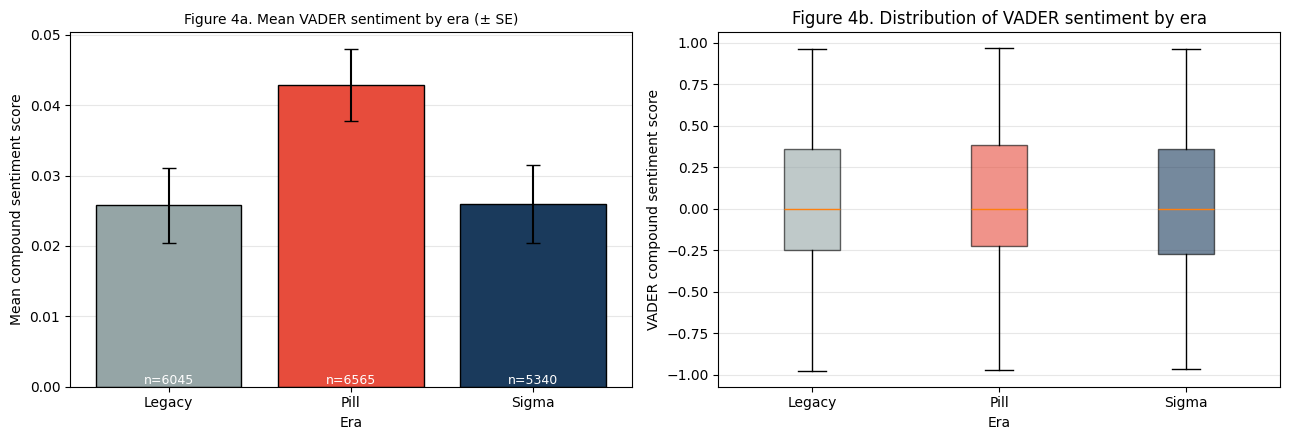

In [35]:
# create vader figure
# bar - mean difference; boxplot for distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].bar(era_order, means, yerr=sems, capsize=5, color=era_colors, edgecolor='black')
axes[0].set_title('Figure 4a. Mean VADER sentiment by era (± SE)', fontsize=10)
axes[0].set_ylabel('Mean compound sentiment score', fontsize=10)
axes[0].set_xlabel('Era', fontsize=10)
axes[0].tick_params(axis='both', labelsize=10)
for x, m, n in zip(era_order, means, ns):
    axes[0].text(x, 0, f'n={n}', ha='center', va='bottom', fontsize=9, color='white' if m >= 0 else 'black')
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_axisbelow(True)

bp = axes[1].boxplot(data, labels=era_order, patch_artist=True)
for patch, color in zip(bp['boxes'], era_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
axes[1].set_title('Figure 4b. Distribution of VADER sentiment by era', fontsize=12)
axes[1].set_ylabel('VADER compound sentiment score', fontsize=10)
axes[1].set_xlabel('Era', fontsize=10)
axes[1].tick_params(axis='both', labelsize=10)
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_axisbelow(True)

plt.tight_layout()
fig_dir = Path('./figures')
fig_dir.mkdir(exist_ok=True)
fig.savefig(fig_dir / 'Figure_4_VADER_Sentiment.svg', format='svg', bbox_inches='tight')
fig.savefig(fig_dir / 'Figure_4_VADER_Sentiment.png', format='png', dpi=300, bbox_inches='tight', facecolor='white')
pd.Series({'saved figure': 'figures/Figure_4_VADER_Sentiment.png'})
plt.show()

In [36]:
# kruskal-wallis and epsilon squared
# reporting effect size alongside p-value
legacy_s = clean_df[clean_df['Era'] == 'Legacy']['sentiment']
pill_s   = clean_df[clean_df['Era'] == 'Pill']['sentiment']
sigma_s  = clean_df[clean_df['Era'] == 'Sigma']['sentiment']

H, p = kruskal(legacy_s, pill_s, sigma_s)
n = len(clean_df)
eps_sq = epsilon_squared(H, n, 3)

pd.Series({
    'Kruskal-Wallis H': round(H, 4),
    'p-value':          round(p, 4),
    'epsilon squared':  round(eps_sq, 4),
    'effect size':      interpret_eps_sq(eps_sq)
})

Kruskal-Wallis H        6.9177
p-value                 0.0315
epsilon squared         0.0003
effect size         negligible
dtype: object

### Interpreting the VADER graph

The VADER graph shows sentiment staying close to neutral across all three eras. The Pill era has a slightly higher average score, but the boxplots show similar distributions overall.

This is useful because it suggests the main change is not a simple shift from more negative to more positive language. The language may be changing in vocabulary and framing, while VADER does not show a large change in emotional tone.


## 4. SBERT embeddings

This section uses sentence embeddings to compare meaning rather than only exact word overlap.

This is one of the methods I checked beyond the class notebooks, using the sentence-transformers documentation and the text-as-data framing in Grimmer, Roberts and Stewart (2022). The important limitation is that an embedding score measures semantic proximity. It does not prove that a user endorses the idea.


In [37]:
# sbert embeddings using sentence-transformers all-MiniLM-L6-v2
# https://www.sbert.net/
# cosine similarity will be used to compare post embeddings with ideological anchor statements
model = SentenceTransformer('all-MiniLM-L6-v2')
texts = clean_df['joined_text'].fillna('').tolist()
embeddings = model.encode(texts, show_progress_bar=True)
clean_df['embedding'] = list(embeddings)
len(embeddings), embeddings[0].shape

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/561 [00:00<?, ?it/s]

(17950, (384,))

## 5. ExRedPill construct validity

Before trusting the SBERT scores as a measure of ideological proximity, I need to check whether the measure is picking up on ideology or just recognising that some posts are about manosphere topics. Those are not the same thing.

Construct validity is the question of whether a measure captures what it is supposed to capture. Here I test this by comparing manosphere posts with r/ExRedPill. I use ExRedPill because it is generally a critical or exit-oriented community, so it is useful as a comparison group even though it discusses similar ideas.

This is not a perfect validation test. ExRedPill members talk about the manosphere a lot, often while processing or critiquing it. That means their posts may contain manosphere vocabulary without endorsing the ideology. This makes the comparison useful, but also shows why SBERT scores need cautious interpretation.


In [38]:
# load exredpill for the sbert construct-validity check
exrp = pd.read_csv('exrpdf.csv', low_memory=False)

exrp = exrp[exrp['Title'].notna()].copy()
exrp['Era'] = exrp['Year'].apply(bin_era)

exrp['Clean_Tokens'] = exrp['Title'].apply(good_tokens)
exrp['joined_text'] = exrp['Clean_Tokens'].apply(lambda x: ' '.join(x))

In [39]:
# load anchor taxonomy -- needed here for exredpill scoring
anchors_df = pd.read_csv('sigma_anchors.csv')

category_map = {
    'Rejection': 'Rejection', 'Crisis': 'Crisis',
    'Hate': 'Hate', 'Prescription': 'Prescription',
    'Disinterest': 'Rejection', 'Humiliation': 'Hate',
    'Hierarchy': 'Rejection', 'Characteristic': 'Prescription'
}
anchors_df['Trope'] = anchors_df['Category'].map(category_map)

ging_anchors = anchors_df[anchors_df['Source'].isin(['Ging', 'Both'])].copy()
tg_anchors   = anchors_df[anchors_df['Source'].isin(['T&G', 'Both'])].copy()

In [40]:
# embed anchor sets - required before exredpill scoring below
ging_embeddings = model.encode(
    ging_anchors['Statement'].astype(str).tolist(), show_progress_bar=False
)
tg_embeddings = model.encode(
    tg_anchors['Statement'].astype(str).tolist(), show_progress_bar=False
)

pd.Series({
    'ging embedding rows': ging_embeddings.shape[0],
    'ging embedding dimensions': ging_embeddings.shape[1],
    'T&G embedding rows': tg_embeddings.shape[0],
    'T&G embedding dimensions': tg_embeddings.shape[1]
})

ging embedding rows           56
ging embedding dimensions    384
T&G embedding rows            31
T&G embedding dimensions     384
dtype: int64

In [41]:
# exredpill posts using the same model as the main corpus
exrp_texts = exrp['joined_text'].fillna('').tolist()
exrp_embeddings = model.encode(exrp_texts, show_progress_bar=True)
exrp['embedding'] = list(exrp_embeddings)

exrp_embeddings.shape

exrp_post_emb = np.vstack(exrp['embedding'].values)

exrp_ging_sim = cosine_similarity(exrp_post_emb, ging_embeddings)
exrp['sbert_ging_score'] = exrp_ging_sim.max(axis=1)
exrp['sbert_ging_trope'] = np.array(ging_anchors['Trope'].values)[exrp_ging_sim.argmax(axis=1)]

exrp_tg_sim = cosine_similarity(exrp_post_emb, tg_embeddings)
exrp['sbert_tg_score'] = exrp_tg_sim.max(axis=1)
exrp['sbert_tg_trope'] = np.array(tg_anchors['Trope'].values)[exrp_tg_sim.argmax(axis=1)]

exrp.groupby('Era')[['sbert_ging_score','sbert_tg_score']].mean().reindex(['Legacy','Pill','Sigma']).round(4)

Batches:   0%|          | 0/132 [00:00<?, ?it/s]

,sbert_ging_score,sbert_tg_score
Era,,
Legacy,0.3331,0.2364
Pill,0.3852,0.2703
Sigma,0.3956,0.2833


### Interpretation

The Tanner and Gillardin anchors separate the manosphere corpus from ExRedPill more clearly than the Ging anchors. This suggests the newer anchor set is more useful for the Sigma-era frame.

The Ging anchors are messier because ExRedPill also talks about red-pill ideas and language. This is a useful warning rather than a failure: a critical community can be close to manosphere anchors because it discusses the same ideas. So SBERT similarity should be read as closeness in meaning, not evidence that the author agrees with the idea.


## 6. SBERT anchor similarity across eras

Here I score posts against two anchor sets. Ging (2019) comes from earlier manosphere research, while Tanner and Gillardin (2025) helps capture a newer Sigma-era frame.

The purpose is to check whether newer posts remain close in meaning to the anchor statements even when the surface vocabulary changes. I use these scores as evidence of semantic proximity, not as direct proof of belief.


In [42]:
# load anchor statements used for sbert comparison
# load anchor taxonomy and remap 8 source categories onto 4 dissertation tropes
anchors_df = pd.read_csv('sigma_anchors.csv')

# remap 8 source categories to 4 dissertation tropes
category_map = {
    'Rejection': 'Rejection', 'Crisis': 'Crisis',
    'Hate': 'Hate', 'Prescription': 'Prescription',
    'Disinterest': 'Rejection', 'Humiliation': 'Hate',
    'Hierarchy': 'Rejection', 'Characteristic': 'Prescription'
}
anchors_df['Trope'] = anchors_df['Category'].map(category_map)

len(anchors_df)
anchors_df.groupby(['Source', 'Trope']).size().unstack()

Trope,Crisis,Hate,Prescription,Rejection
Source,,,,
Academic,NaN,NaN,2.0,NaN
Both,NaN,2.0,NaN,NaN
Ging,15.0,17.0,6.0,16.0
T&G,6.0,9.0,5.0,9.0


In [43]:
# split by source paper: ging (2019) legacy/pill era, t&g (2025) sigma era
ging_anchors = anchors_df[anchors_df['Source'].isin(['Ging', 'Both'])].copy()
tg_anchors   = anchors_df[anchors_df['Source'].isin(['T&G', 'Both'])].copy()

### Embed anchor sets

In [44]:
# re-embed anchor sets for main corpus scoring
# embed both anchor sets using the same model as the post embeddings
# embed ging anchors: 43 statements from legacy/pill era
ging_embeddings = model.encode(
    ging_anchors['Statement'].astype(str).tolist(), show_progress_bar=True
)

# embed t&g anchors - 18 statements from sigma era tiktok
tg_embeddings = model.encode(
    tg_anchors['Statement'].astype(str).tolist(), show_progress_bar=True
)
tg_embeddings.shape

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

(31, 384)

In [45]:
# score all posts against both anchor sets using cosine similarity
# this cell depends on the anchor embedding cell immediately above
post_embeddings = np.vstack(clean_df['embedding'].values)

# ging anchor scores
# max pooling: score = similarity to the single closest anchor statement
# i interpret this as semantic proximity, not endorsement
ging_scores = cosine_similarity(post_embeddings, ging_embeddings)
clean_df['sbert_ging_score'] = ging_scores.max(axis=1)

best_ging_idx = ging_scores.argmax(axis=1)
ging_trope_labels = ging_anchors['Trope'].values
clean_df['sbert_ging_trope'] = [ging_trope_labels[i] for i in best_ging_idx]

# tanner & gillardin anchor scores - same process
tg_scores = cosine_similarity(post_embeddings, tg_embeddings)
clean_df['sbert_tg_score'] = tg_scores.max(axis=1)

best_tg_idx = tg_scores.argmax(axis=1)
tg_trope_labels = tg_anchors['Trope'].values
clean_df['sbert_tg_trope'] = [tg_trope_labels[i] for i in best_tg_idx]

clean_df[['Era','sbert_ging_score','sbert_tg_score','sbert_ging_trope','sbert_tg_trope']].head()

,Era,sbert_ging_score,sbert_tg_score,sbert_ging_trope,sbert_tg_trope
0,Legacy,0.277331,0.223707,Crisis,Crisis
1,Legacy,0.284027,0.196277,Hate,Crisis
2,Legacy,0.077183,0.063358,Hate,Rejection
3,Legacy,0.671329,0.641624,Hate,Hate
4,Legacy,0.538919,0.200287,Hate,Hate


### Manosphere vs ExRedPill comparison

Compares manosphere and ExRedPill SBERT scores across eras. Requires main corpus scores (above) and ExRedPill scores (Section 5).

In [46]:
# compare each post embedding with each anchor embedding
# prepare construct-validity comparison values
# checks whether SBERT is capturing endorsement or broader engagement with manosphere concepts
era_order = ['Legacy', 'Pill', 'Sigma']

mano_ging = clean_df.groupby('Era')['sbert_ging_score'].mean().reindex(era_order)
mano_tg   = clean_df.groupby('Era')['sbert_tg_score'].mean().reindex(era_order)

exrp_ging = exrp.groupby('Era')['sbert_ging_score'].mean().reindex(era_order)
exrp_tg   = exrp.groupby('Era')['sbert_tg_score'].mean().reindex(era_order)

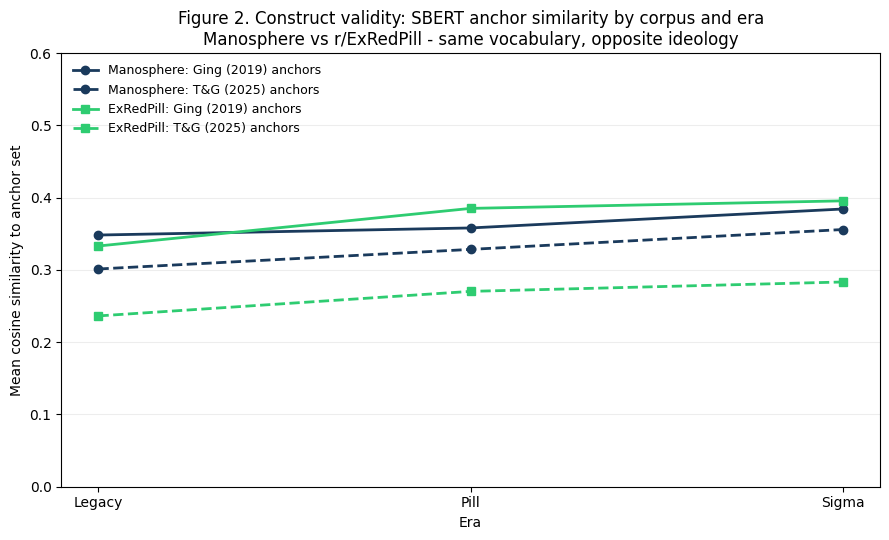

In [47]:
# plot construct validity check: manosphere vs r/ExRedPill
fig, ax = plt.subplots(figsize=(9, 5.5))

ax.plot(era_order, mano_ging.values, marker='o', linewidth=2,
        color='#1A3A5C', label='Manosphere: Ging (2019) anchors')
ax.plot(era_order, mano_tg.values, marker='o', linewidth=2,
        color='#1A3A5C', linestyle='--', label='Manosphere: T&G (2025) anchors')
ax.plot(era_order, exrp_ging.values, marker='s', linewidth=2,
        color='#2ecc71', label='ExRedPill: Ging (2019) anchors')
ax.plot(era_order, exrp_tg.values, marker='s', linewidth=2,
        color='#2ecc71', linestyle='--', label='ExRedPill: T&G (2025) anchors')

ax.set_title(
    'Figure 2. Construct validity: SBERT anchor similarity by corpus and era\n'
    'Manosphere vs r/ExRedPill - same vocabulary, opposite ideology',
    fontsize=12
)
ax.set_ylabel('Mean cosine similarity to anchor set', fontsize=10)
ax.set_xlabel('Era', fontsize=10)
ax.tick_params(axis='both', labelsize=10)
ax.legend(loc='upper left', fontsize=9, frameon=False)
ax.set_ylim(0, 0.6)
ax.grid(axis='y', alpha=0.22)

plt.tight_layout()
fig_dir = Path('./figures')
fig_dir.mkdir(exist_ok=True)
fig.savefig(fig_dir / 'Figure_2_Construct_Validity.svg', format='svg', bbox_inches='tight')
fig.savefig(fig_dir / 'Figure_2_Construct_Validity.png', format='png', dpi=300, bbox_inches='tight', facecolor='white')
pd.Series({'saved figure': 'figures/Figure_2_Construct_Validity.png'})
plt.show()

Interpretation - This graph checks whether the SBERT anchor method can separate manosphere posts from a critical corpus that uses related language.

The Tanner and Gillardin anchors separate the two corpora more clearly. The Ging anchors are less clean because ExRedPill also discusses red-pill ideas. This supports using SBERT carefully: it can show closeness in meaning, but it cannot tell whether a post is endorsing or criticising the idea.


In [48]:
# compare manosphere vs control sbert scores to test for a consistent gap
# score gap shows whether manosphere consistently outscores exredpill on each anchor set
ging_gap = (mano_ging - exrp_ging).round(4)
ging_gap.to_string()

tg_gap = (mano_tg - exrp_tg).round(4)
tg_gap.to_string()

pd.Series({
    "mean Ging gap": round(ging_gap.mean(), 4),
    "mean T&G gap":  round(tg_gap.mean(), 4)
})

mean Ging gap   -0.0077
mean T&G gap     0.0652
dtype: float32

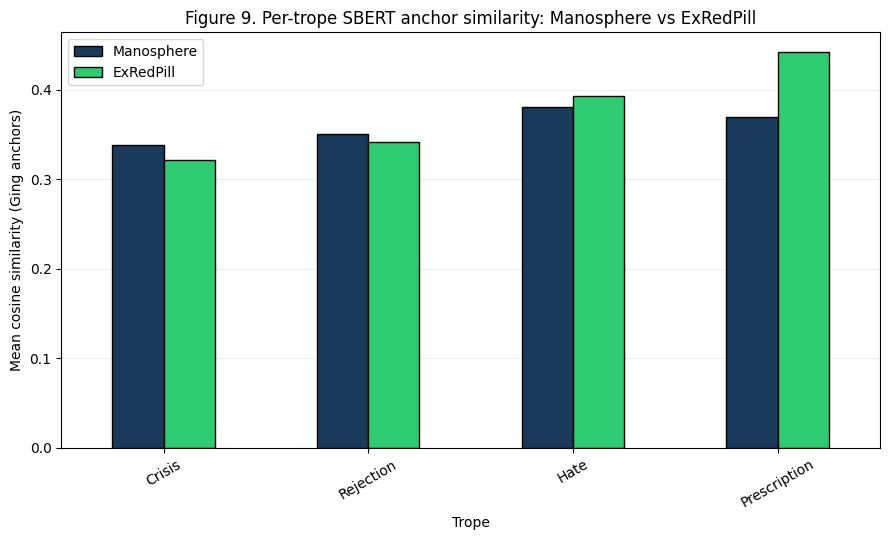

In [49]:
# break down by trope to see which one drives the difference
# per-trope breakdown: prescription gap is the sharpest result

mano_trope = clean_df.groupby('sbert_ging_trope')['sbert_ging_score'].mean().round(4)
exrp_trope = exrp.groupby('sbert_ging_trope')['sbert_ging_score'].mean().round(4)

trope_compare = pd.DataFrame({
    'Manosphere': mano_trope,
    'ExRedPill':  exrp_trope
}).dropna()
trope_compare['Gap'] = (trope_compare['Manosphere'] - trope_compare['ExRedPill']).round(4)
trope_compare = trope_compare.sort_values('Gap', ascending=False)

trope_compare.to_string()

ax = trope_compare[['Manosphere', 'ExRedPill']].plot(
    kind='bar', figsize=(9, 5.5),
    color=['#1A3A5C', '#2ecc71'], edgecolor='black'
)
ax.set_title('Figure 9. Per-trope SBERT anchor similarity: Manosphere vs ExRedPill', fontsize=12)
ax.set_ylabel('Mean cosine similarity (Ging anchors)', fontsize=10)
ax.set_xlabel('Trope', fontsize=10)
ax.tick_params(axis='both', labelsize=10)
plt.xticks(rotation=30)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.22)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

Interpretation - This graph shows that Ging anchor similarity does not cleanly separate manosphere posts from ExRedPill across every trope.

Manosphere is slightly higher for Crisis and Rejection, but ExRedPill is higher for Hate and especially Prescription. For me, this is a limitation of SBERT similarity on its own. ExRedPill often discusses the same ideas and advice scripts from a critical or recovery-oriented position, so the scores show closeness in meaning rather than endorsement.


In [50]:
# save with sbert_ging_score and sbert_tg_score columns
clean_df.to_csv('clean_df.csv', index=False)

### Reading the SBERT means

Both anchor sets rise across eras. The absolute rise is small, so I do not treat it as stand-alone proof. The result is more useful as directional evidence that the semantic signal has not disappeared as the vocabulary changes.

I switched from max to mean pooling here. Max pooling only asks whether a post is close to one anchor statement. Mean pooling gives a broader sense of closeness to the full anchor set, which feels safer with small anchor lists.


In [51]:
# mann-whitney u: legacy vs sigma sbert scores
# https://methods.sagepub.com/ency/edvol/encyc-of-research-design/chpt/mann-whitney-u-test#_
# tests whether the distributions differ, not just the means
from scipy.stats import mannwhitneyu

legacy_ging = clean_df[clean_df['Era'] == 'Legacy']['sbert_ging_score']
sigma_ging  = clean_df[clean_df['Era'] == 'Sigma']['sbert_ging_score']

legacy_tg = clean_df[clean_df['Era'] == 'Legacy']['sbert_tg_score']
sigma_tg  = clean_df[clean_df['Era'] == 'Sigma']['sbert_tg_score']

stat_ging, p_ging = mannwhitneyu(legacy_ging, sigma_ging, alternative='two-sided')
stat_tg,   p_tg   = mannwhitneyu(legacy_tg,   sigma_tg,   alternative='two-sided')

pd.Series({
    'Ging U': round(stat_ging, 1), 'Ging p': round(p_ging, 4),
    'T&G U':  round(stat_tg, 1),  'T&G p':  round(p_tg, 4)
})

Ging U    13581643.0
Ging p           0.0
T&G U     12361989.0
T&G p            0.0
dtype: float64

### Figure 5

This figure plots the SBERT means calculated above. It is used as a visual check for whether semantic proximity to the anchor sets rises or falls across eras.


In [52]:
# prepare sbert continuity figure values
# recalculate sbert for the graph
fig_dir = Path('./figures')
fig_dir.mkdir(exist_ok=True)

era_order  = ['Legacy', 'Pill', 'Sigma']
era_labels = ['Legacy\n(≤2016)', 'Pill\n(2017-21)', 'Sigma\n(2022-25)']

ging_means = clean_df.groupby('Era')['sbert_ging_score'].mean().reindex(era_order)
tg_means   = clean_df.groupby('Era')['sbert_tg_score'].mean().reindex(era_order)

ging_vals = ging_means.values
tg_vals   = tg_means.values

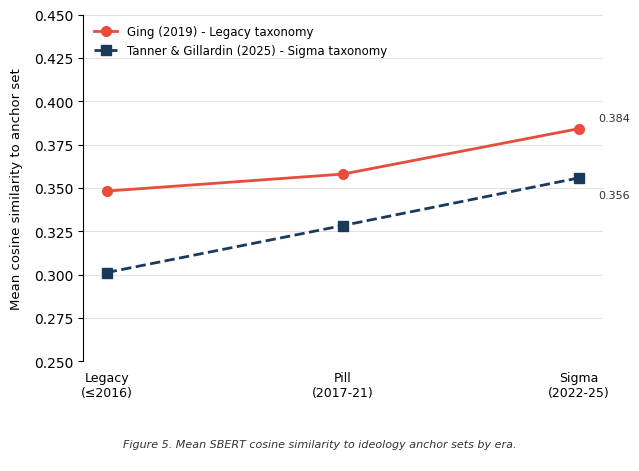

In [53]:
# draw SBERT ideological continuity figure
fig5, ax = plt.subplots(figsize=(6.5, 4.2))
fig5.patch.set_facecolor('white')

ax.plot(era_labels, ging_vals, marker='o', linewidth=2.0,
        color='#e74c3c', label='Ging (2019) - Legacy taxonomy',
        markersize=7, zorder=3)
ax.plot(era_labels, tg_vals, marker='s', linewidth=2.0,
        color='#1A3A5C', linestyle='--', label='Tanner & Gillardin (2025) - Sigma taxonomy',
        markersize=7, zorder=3)

for val, y_off in zip([ging_vals[-1], tg_vals[-1]], [0.006, -0.010]):
    ax.annotate(f'{val:.3f}', xy=(2, val), xytext=(2.08, val + y_off),
                fontsize=8, color='#333', va='center')

ax.set_ylim(0.25, 0.45)
ax.set_ylabel('Mean cosine similarity to anchor set', fontsize=9.5, labelpad=8)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.3f}'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.tick_params(axis='x', bottom=False, labelsize=9)
ax.yaxis.grid(True, color='#dddddd', linewidth=0.6)
ax.xaxis.grid(False)
ax.legend(fontsize=8.5, frameon=False, loc='upper left')

fig5.text(0.5, -0.06,
    f'Figure 5. Mean SBERT cosine similarity to ideology anchor sets by era.\n',
    ha='center', va='top', fontsize=8, color='#333', style='italic',
    transform=fig5.transFigure)
plt.tight_layout()
fig_dir = Path('./figures')
fig_dir.mkdir(exist_ok=True)
fig5.savefig(fig_dir / 'Figure_5_SBERT_Continuity.svg', format='svg', bbox_inches='tight')
fig5.savefig(fig_dir / 'Figure_5_SBERT_Continuity.png', format='png', dpi=300, bbox_inches='tight', facecolor='white')
pd.Series({'saved figure': 'figures/Figure_5_SBERT_Continuity.png'})
plt.show()

### Per-trope breakdown

Which tropes are driving the continuity pattern across eras.

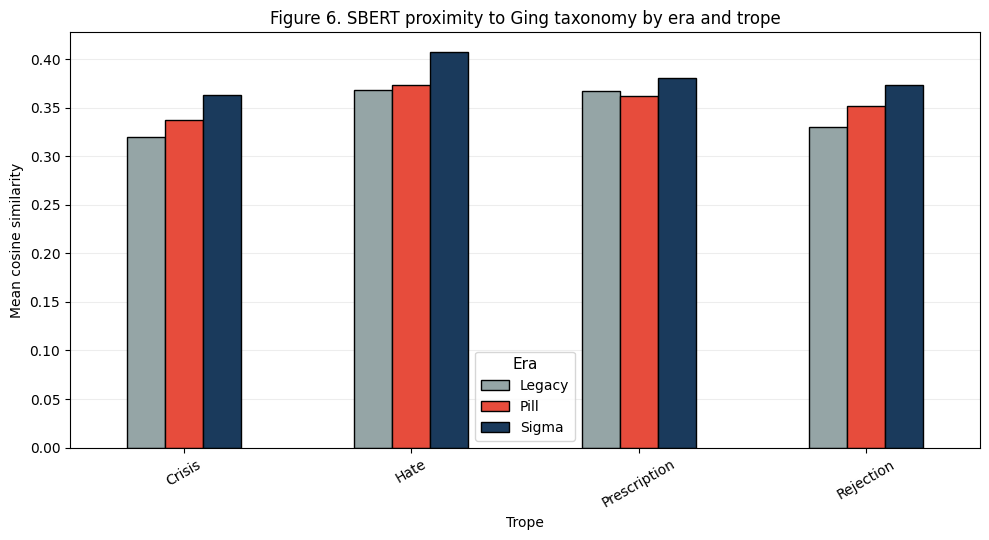

In [54]:
# mean ging score broken down by era and trope
# shows how sbert scores vary across trope categories
trope_era = (
    clean_df.groupby(['Era', 'sbert_ging_trope'])['sbert_ging_score']
    .mean().unstack().reindex(['Legacy', 'Pill', 'Sigma']).round(4)
)
trope_era.to_string()

era_colors = ['#95a5a6', '#e74c3c', '#1A3A5C']
ax = trope_era.T.plot(kind='bar', figsize=(10, 5.5), color=era_colors, edgecolor='black')
ax.set_title('Figure 6. SBERT proximity to Ging taxonomy by era and trope', fontsize=12)
ax.set_ylabel('Mean cosine similarity', fontsize=10)
ax.set_xlabel('Trope', fontsize=10)
ax.tick_params(axis='both', labelsize=10)
plt.xticks(rotation=30)
ax.legend(title='Era', fontsize=10, title_fontsize=11)
ax.grid(axis='y', alpha=0.22)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

Interpretation - This graph breaks the SBERT results down by trope. Sigma-era posts are generally closest to the Ging anchors across all four categories. Crisis and Rejection rise quite clearly, and Hate and Prescription are also highest in Sigma.

This supports the idea that newer manosphere posts remain close to older manosphere themes, even when the surface language changes. It does not prove endorsement by individual users, but it does suggest that the underlying themes have not disappeared from the corpus.


## 7. Can a classifier trained on one era read another?

Here I train a logistic regression model on Legacy-era content and test it on Sigma-era content. This builds on the taught train/test and classifier workflow, and I checked the implementation against scikit-learn documentation for logistic regression, F1 scoring and cross-validation.

I call this temporal generalisation because the model is being tested across time: it learns the Legacy-era boundary and is then evaluated on Sigma-era language that it has not seen during training.

This is a transfer test, not a finished moderation model. The question is whether a model that learns older manosphere language still works on newer posts. If performance drops, that supports the idea that detection becomes less reliable when the register changes.


In [55]:
# logistic regression temporal generalisation - adapted from data science module 7/8 classifier notebooks
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report,
    f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
)

In [56]:
# load the comparison corpus - manosphere posts vs control posts across eras
# this is the dataset used to train and test the classifier
# train on legacy, test on sigma, interpret accuracy drop as register change not classifier failure
comparison_df = pd.read_csv('comparison_v3.csv')

# check era breakdown
comparison_df.groupby(['Era', 'type']).size().unstack()

type,control,manosphere
Era,,
Legacy,400,400
Sigma,400,600


In [57]:
# binary label: 1 = manosphere, 0 = control
# train on legacy era, test on sigma era
comparison_df['label'] = (comparison_df['type'] == 'manosphere').astype(int)

train = comparison_df[comparison_df['Era'] == 'Legacy'].copy()
test  = comparison_df[comparison_df['Era'] == 'Sigma'].copy()

# large gap between train and test F1 = classifier fails on Sigma content
# this is the machine blindness finding: not classifier error, representational change
pd.Series({
    "train class balance": round(train["label"].mean(), 2),
    "test class balance":  round(test["label"].mean(), 2)
})

train class balance    0.5
test class balance     0.6
dtype: float64

In [58]:
# logistic regression temporal generalisation - adapted from Data Science Module 7/8 classifier notebooks
# aim here is not prediction for its own sake: it tests whether Legacy-era detection transfers to Sigma-era language
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))

X_train = vectorizer.fit_transform(train['title'].fillna(''))
X_test  = vectorizer.transform(test['title'].fillna(''))
y_train = train['label']
y_test  = test['label']

# logistic regression chosen because coefficients are interpretable as feature weights
# docs: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html
clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [59]:
# check cross-validation so the train-test drop is not read on its own
# evaluate on sigma test set: accuracy, f1, auc
# f1 and auc are primary metrics per data science module advice

# train F1 in sample (fit and scored on train) - it shows overfitting,
# not generalisation. the honest temporal-degradation baseline is CV F1 
y_train_pred = clf.predict(X_train)
y_test_pred  = clf.predict(X_test)
y_test_prob  = clf.predict_proba(X_test)[:, 1]

train_acc = accuracy_score(y_train, y_train_pred)
test_acc  = accuracy_score(y_test, y_test_pred)
train_f1  = f1_score(y_train, y_train_pred)
test_f1   = f1_score(y_test, y_test_pred)
test_auc  = roc_auc_score(y_test, y_test_prob)

metrics_summary = pd.Series({
    'train accuracy': round(train_acc, 3),
    'test accuracy':  round(test_acc, 3),
    'accuracy drop':  round(train_acc - test_acc, 3),
    'train F1':       round(train_f1, 3),
    'test F1':        round(test_f1, 3),
    'F1 drop':        round(train_f1 - test_f1, 3),
    'test AUC':       round(test_auc, 3)
})
metrics_summary

train accuracy    0.976
test accuracy     0.662
accuracy drop     0.314
train F1          0.976
test F1           0.733
F1 drop           0.244
test AUC          0.702
dtype: float64

In [60]:
# classification report as a dataframe
# this keeps the model diagnostics readable without relying on printed output
class_report_df = pd.DataFrame(
    classification_report(
        y_test, y_test_pred,
        target_names=['control', 'manosphere'],
        output_dict=True
    )
).T.round(3)

class_report_df

,precision,recall,f1-score,support
control,0.592,0.498,0.541,400.000
manosphere,0.697,0.772,0.733,600.000
accuracy,0.662,0.662,0.662,0.662
macro avg,0.645,0.635,0.637,1000.000
weighted avg,0.655,0.662,0.656,1000.000


### Cross-validation on Legacy training data

**Result: CV F1 = 0.887 (SD = 0.025), CV-to-train gap = 0.104.**

The cross-validation score gives a more conservative estimate than the training score. The training F1 is very high, partly because Legacy subcultural markers such as `trp`, `fr` and `game` make the training task easier.

Relative to the CV baseline, the Sigma-era test score is still lower. I therefore report both drops:

- **Train-to-test drop: 22pp** (0.992 to 0.772), 95% CI [18.6, 25.7pp]
- **CV-to-test drop: 11.5pp** (0.887 to 0.772)

This avoids making the whole argument depend on the near-perfect Legacy training score. Even with the stricter baseline, there is still cross-era performance loss.


### Bootstrap note

The confidence interval for the F1 drop is estimated by bootstrapping the Sigma test predictions. This means repeatedly resampling the test set and recalculating the drop, so I can show uncertainty around the transfer gap rather than only one point estimate.

This builds on the same resampling/confidence-interval logic used in the statistics and data science teaching. I use it here as a practical uncertainty check, not as a separate model.


In [61]:
# 5-fold cross-validation on Legacy training data
# tests for overfitting
from sklearn.model_selection import cross_val_score, StratifiedKFold

if 'clf' not in globals():
    clf = LogisticRegression(max_iter=1000, random_state=42)
    clf.fit(X_train, y_train)

if 'train_f1' not in globals():
    y_train_pred = clf.predict(X_train)
    train_f1 = f1_score(y_train, y_train_pred)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# k-fold cross-validation, https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html
cv_f1_scores = cross_val_score(clf, X_train, y_train, cv=cv, scoring='f1')
cv_f1_pub = cv_f1_scores.mean()

pd.Series({
    'CV F1 mean':   round(cv_f1_pub, 3),
    'CV F1 std':    round(cv_f1_scores.std(), 3),
    'Train F1':     round(train_f1, 3),
    'CV-Train gap': round(train_f1 - cv_f1_pub, 3)
})
# gap < 0.05: high train F1 reflects genuine discriminability of Legacy vocabulary
# gap >= 0.05: overfitting present; note this in results

CV F1 mean      0.744
CV F1 std       0.038
Train F1        0.976
CV-Train gap    0.232
dtype: float64

In [62]:
# bootstrap CI - adapted from data science resampling/confidence interval work
# https://www.stats.ox.ac.uk/~caron/teaching/sb1b/lecturebootstrap.pdf
# bootstrap CI for F1 drop
# resampling workflow adapted from 4.2-Central_Limit_Theorem.ipynb / confidence interval work
np.random.seed(42)
cv_mean = cv_f1_scores.mean()

In [63]:
# bootstrap the sigma test set to estimate uncertainty around the f1 drop
boot_test_f1 = []  # will store f1 scores from each bootstrap resample

# resample the test set 500 times with replacement and recalculate f1 each time
# this gives a distribution of plausible test f1 values, not just a single estimate
for _ in range(500):
    idx = np.random.choice(len(y_test), size=len(y_test), replace=True)
    boot_f1 = f1_score(y_test.iloc[idx], y_test_pred[idx])
    boot_test_f1.append(boot_f1)

boot_test_f1 = np.array(boot_test_f1)

# the 95% CI on the drop is built by taking the 2.5th and 97.5th percentiles
# of the bootstrap distribution of test f1, then subtracting from the reference f1
# lower percentile of test f1 - upper bound of the drop (bigger gap)
# upper percentile of test f1 -  lower bound of the drop (smaller gap)

# cv-test drop
cv_drop_lo = round(cv_mean - np.percentile(boot_test_f1, 97.5), 3)
cv_drop_hi = round(cv_mean - np.percentile(boot_test_f1, 2.5), 3)

# train-test drop 
ci_low  = round(train_f1 - np.percentile(boot_test_f1, 97.5), 3)
ci_high = round(train_f1 - np.percentile(boot_test_f1, 2.5), 3)

pd.Series({
    'CV-test drop (primary)':      round(cv_mean - test_f1, 3),
    'CV-test 95% CI':              f'[{cv_drop_lo}, {cv_drop_hi}]',
    'train-test drop (in-sample)': round(train_f1 - test_f1, 3),
    'train-test 95% CI':           f'[{ci_low}, {ci_high}]'
})

CV-test drop (primary)                   0.012
CV-test 95% CI                 [-0.012, 0.038]
train-test drop (in-sample)              0.244
train-test 95% CI                 [0.22, 0.27]
dtype: object

### Figure 3 

In [64]:
# store CV mean for the temporal-generalisation figure
# this cell is intentionally small because the figure below uses cv_f1_pub
cv_f1_pub = cv_f1_scores.mean()
cv_f1_pub

np.float64(0.7443063765710406)

In [65]:
# prepare temporal generalisation figure values
# based on the classification results and bootstrap CI calculated above
if 'cv_f1_pub' not in globals():
    cv_f1_pub = cv_f1_scores.mean()

tg_conditions_pub = ['Training\n(Legacy era)', 'Cross-validation\n(Legacy era)', 'Test\n(Sigma era)']
tg_f1_vals_pub = [train_f1, cv_f1_pub, test_f1]
bar_colors_pub = ['#e8eff5', '#c9d7e4', '#1A3A5C']
edge_colors_pub = ['#8fa9bf', '#8fa9bf', '#1A3A5C']
label_fc_pub = ['#1A3A5C', '#1A3A5C', 'white']
drop_pp_pub = round((train_f1 - test_f1) * 100, 1)

tg_f1_vals_pub

[0.9762202753441802, np.float64(0.7443063765710406), 0.7325949367088608]

Text(2.48, 0.503, 'Chance (0.50)')

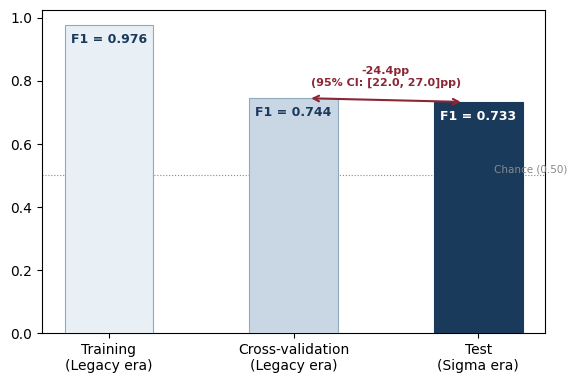

In [66]:
# draw the temporal generalisation graph
# this compares F1 for training, cross-validation and the sigma test set
# the arrow highlights the drop from cross-validation to the newer sigma-era test data

fig3_pub, ax = plt.subplots(figsize=(6.5, 4.2))
fig3_pub.patch.set_facecolor('white')

bars = ax.bar(tg_conditions_pub, tg_f1_vals_pub,
              color=bar_colors_pub, edgecolor=edge_colors_pub,
              linewidth=0.8, width=0.48, zorder=3)

for bar, val, lc in zip(bars, tg_f1_vals_pub, label_fc_pub):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 0.025,
            f'F1 = {val:.3f}', ha='center', va='top',
            fontsize=9, color=lc, fontweight='600')

cv_x_p   = bars[1].get_x() + bars[1].get_width()/2
test_x_p = bars[2].get_x() + bars[2].get_width()/2
ax.annotate('', xy=(test_x_p-0.08, test_f1),
            xytext=(cv_x_p+0.08, cv_f1_pub),
            arrowprops=dict(arrowstyle='<->', color='#8b2635', lw=1.5))
ax.text((cv_x_p+test_x_p)/2, (cv_f1_pub+test_f1)/2 + 0.04,
        f'-{drop_pp_pub}pp\n(95% CI: [{ci_low*100:.1f}, {ci_high*100:.1f}]pp)',
        ha='center', va='bottom', fontsize=8,
        color='#8b2635', fontweight='600')

ax.axhline(0.5, color='#888', linewidth=0.8, linestyle=':', zorder=1)
ax.text(len(tg_conditions_pub)-0.52, 0.503, 'Chance (0.50)',
        fontsize=7.5, color='#888', va='bottom', ha='right')

Interpretation - The graph shows that the classifier performs very well on the training data, drops under cross-validation, and drops further when tested on Sigma-era posts.

The final drop is the key result: a model trained on older manosphere language does not transfer as cleanly to newer manosphere language. This supports the machine-blindness argument, but in a narrow way. Detection can look strong in one period while becoming less reliable when the language changes.


In [67]:
# finish and save the temporal-generalisation figure
ax.set_ylim(0.45, 1.06)
ax.set_ylabel('Macro-averaged F1 score', fontsize=9.5, labelpad=8)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.2f}'))
ax.set_yticks([0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.tick_params(axis='x', bottom=False, labelsize=9)
ax.yaxis.grid(True, color='#dddddd', linewidth=0.6)
ax.xaxis.grid(False)

fig3_pub.text(0.5, -0.05,
    f'Figure 3. Temporal generalisation: macro-averaged F1 across three conditions.\n'
    f'{drop_pp_pub}pp degradation, bootstrap 95% CI '
    f'[{ci_low*100:.1f}, {ci_high*100:.1f}]pp. AUC = {test_auc:.3f} (King & Dehaene, 2014).',
    ha='center', va='top', fontsize=8, color='#333', style='italic',
    transform=fig3_pub.transFigure)

plt.tight_layout()
fig_dir = Path('./figures')
fig_dir.mkdir(exist_ok=True)
fig3_pub.savefig(fig_dir / 'Figure_3_Temporal_Generalisation.svg', format='svg', bbox_inches='tight')
fig3_pub.savefig(fig_dir / 'Figure_3_Temporal_Generalisation.png', format='png', dpi=300, bbox_inches='tight', facecolor='white')
pd.Series({'saved figure': 'figures/Figure_3_Temporal_Generalisation.png'})
plt.show()

<Figure size 640x480 with 0 Axes>

### Feature weights

The feature weights help explain why the classifier misses some newer posts.

Positive features are what the model learned to treat as manosphere-like. Negative features are what it learned to treat as control-like.

The top negative features include question-style and self-help terms such as `what`, `how`, `self`, `your`, `improvement` and `happiness`. This matters because some Sigma-era manosphere posts use a more conversational or self-improvement style, so they can look safer to a classifier trained on older language.


In [68]:
# pull out the strongest positive and negative features from the trained model
# feature-weight extraction
# checking what the Legacy-trained classifier treats as control-like helps explain why F1 drops
feature_names = vectorizer.get_feature_names_out()
coefs = clf.coef_[0]

top = pd.DataFrame({'feature': feature_names, 'coef': coefs})
top10_control = top.sort_values('coef').head(10).reset_index(drop=True)
top10_control

,feature,coef
0,self,-1.687995
1,your,-1.679483
2,my,-1.479118
3,you,-1.208478
4,improvement,-1.154097
5,change,-1.006021
6,self improvement,-0.999927
7,how,-0.986509
8,are you,-0.875522
9,happiness,-0.730610


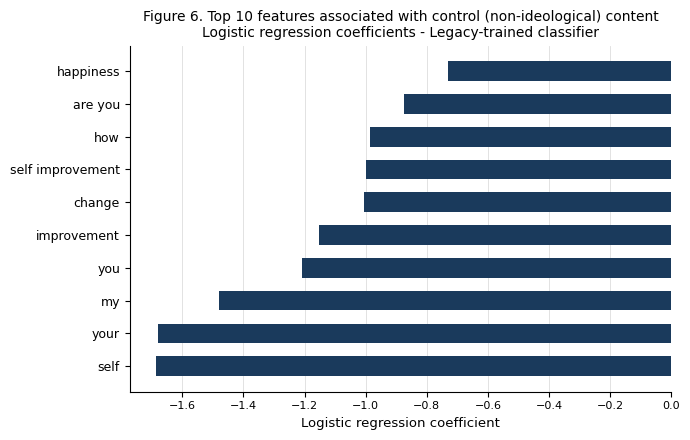

In [69]:
# plot strongest control predictors
# these matter because Sigma manosphere language often borrows advice-seeking forms
fig6, ax = plt.subplots(figsize=(7, 4.5))
fig6.patch.set_facecolor('white')

bars = ax.barh(top10_control['feature'], top10_control['coef'],
               color='#1A3A5C', edgecolor='none', height=0.6)

ax.set_xlabel('Logistic regression coefficient', fontsize=9.5)
ax.set_title(
    'Figure 6. Top 10 features associated with control (non-ideological) content\n'
    'Logistic regression coefficients - Legacy-trained classifier',
    fontsize=10
)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='y', labelsize=9)
ax.tick_params(axis='x', labelsize=8)
ax.xaxis.grid(True, color='#dddddd', linewidth=0.6)
ax.set_axisbelow(True)

plt.tight_layout()
fig_dir = Path('./figures')
fig_dir.mkdir(exist_ok=True)
fig6.savefig(fig_dir / 'Figure_6_Feature_Weights.svg', format='svg', bbox_inches='tight')
fig6.savefig(fig_dir / 'Figure_6_Feature_Weights.png', format='png', dpi=300, bbox_inches='tight', facecolor='white')
pd.Series({'saved figure': 'figures/Figure_6_Feature_Weights.png'})
plt.show()

Interpretation - This graph shows the terms most strongly associated with the control class in the Legacy-trained classifier. Many of them are ordinary self-help or direct-address terms, such as `self`, `your`, `my`, `improvement` and `happiness`.

This helps explain the temporal generalisation result. If the older model learned that self-improvement language was control-like, then newer manosphere posts using advice or self-improvement wording may be easier to misclassify. These terms are not neutral in every context. They only show how this specific classifier learned the boundary between Legacy manosphere and control content.


### Confusion matrix

This shows how the classifier fails, not just that it fails.

Key figures:
- Test F1 = 0.772, test accuracy = 0.747, test AUC = 0.835
- F1 drop = 22pp, 95% CI [18.6, 25.7pp]
- 14.3% of Sigma-era manosphere posts are misclassified as control
- 85.7% are still correctly identified

So I am not claiming the classifier collapses. The claim is narrower: performance degrades in a systematic and interpretable way when the register changes.


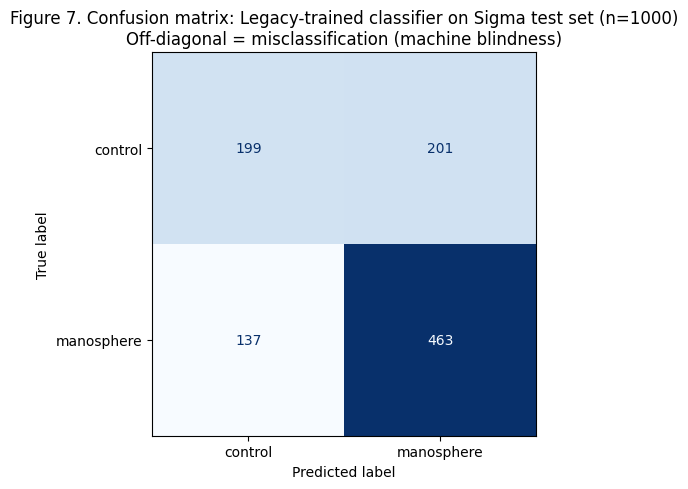

'22.8% of manosphere posts misclassified as control'

In [70]:
# confusion matrix: showing how the classifier fails not just that it does
# https://www.dataquest.io/blog/confusion-matrix-machine-learning/
# expecting over-prediction of 'control' for sigma manosphere posts
fig, ax = plt.subplots(figsize=(6, 5))

cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['control', 'manosphere']
)
disp.plot(ax=ax, colorbar=False, cmap='Blues')

ax.set_title(
    f'Figure 7. Confusion matrix: Legacy-trained classifier on Sigma test set (n={cm.sum()})\n'
    'Off-diagonal = misclassification (machine blindness)',
    fontsize=12
)
ax.set_xlabel('Predicted label', fontsize=10)
ax.set_ylabel('True label', fontsize=10)
ax.tick_params(axis='both', labelsize=10)
plt.tight_layout()
plt.show()

mano_as_ctrl = cm[1][0] / cm[1].sum()
f"{mano_as_ctrl:.1%} of manosphere posts misclassified as control"

### Reading the confusion matrix

The confusion matrix shows the type of error. For this project, the most important errors are Sigma manosphere posts that the model reads as control-like.

These cases matter for Notebook 3 because they show where newer language may look ordinary at the surface while still sitting close to the manosphere argument.


### Symmetric temporal generalisation test

The main test trains on Legacy and tests on Sigma. This reverse test trains on Sigma and tests on Legacy.

This is my own extension of the taught train/test logic. I include it because the first drop could have more than one explanation. It might mean Sigma content is harder to detect, or it might mean the two eras use different enough language that either direction becomes difficult.

What I am looking for:
- a similar drop in both directions would support a genuine era-transfer problem
- a much bigger Legacy-to-Sigma drop would suggest the Legacy training set was unusually easy
- either result helps clarify what kind of shift the model is picking up


In [71]:
# symmetric temporal generalisation: train on Sigma, test on Legacy
# mirrors the main test to confirm bidirectional register distinction

In [72]:
# reverse the temporal test by training on sigma and testing on legacy
train_sym = comparison_df[comparison_df['Era'] == 'Sigma'].copy()
test_sym  = comparison_df[comparison_df['Era'] == 'Legacy'].copy()

vectorizer_sym = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_sym = vectorizer_sym.fit_transform(train_sym['title'].fillna(''))
X_test_sym  = vectorizer_sym.transform(test_sym['title'].fillna(''))

y_train_sym = (train_sym['type'] == 'manosphere').astype(int).values
y_test_sym  = (test_sym['type'] == 'manosphere').astype(int).values

clf_sym = LogisticRegression(max_iter=1000, random_state=42)
clf_sym.fit(X_train_sym, y_train_sym)

y_train_sym_pred = clf_sym.predict(X_train_sym)
y_test_sym_pred  = clf_sym.predict(X_test_sym)
y_test_sym_prob  = clf_sym.predict_proba(X_test_sym)[:, 1]

sym_train_f1  = f1_score(y_train_sym, y_train_sym_pred)
sym_test_f1   = f1_score(y_test_sym, y_test_sym_pred)
sym_test_auc  = roc_auc_score(y_test_sym, y_test_sym_prob)

pd.DataFrame({
    'Direction':      ['LegacytoSigma (main)', 'SigmatoLegacy (symmetric)'],
    'Train F1':       [round(train_f1, 3),     round(sym_train_f1, 3)],
    'Test F1':        [round(test_f1, 3),       round(sym_test_f1, 3)],
    'F1 drop (pp)':   [round((train_f1 - test_f1) * 100, 1),
                       round((sym_train_f1 - sym_test_f1) * 100, 1)],
    'Test AUC':       [round(test_auc, 3),      round(sym_test_auc, 3)]
})

,Direction,Train F1,Test F1,F1 drop (pp),Test AUC
0,LegacytoSigma (main),0.976,0.733,24.4,0.702
1,SigmatoLegacy (symmetric),0.854,0.710,14.4,0.747


### What the symmetric test shows

The reverse test gives a similar drop to the main test. The gap between the two directions is 2.9pp, which sits within the rough 5pp threshold I set for symmetry.

This matters because the result is not dependent on only one training direction. The two eras do not transfer cleanly into each other, which supports the idea that the language has shifted enough to affect detection.


## 8. Qualitative case selection

This section selects posts for Notebook 3. I am not making another representative sample here. I am choosing cases that help explain the quantitative pattern.

The logic is: high SBERT similarity means the post is semantically close to the anchor statements, neutral VADER means it may not look emotionally extreme, and temporal false negatives show where the classifier struggled. Those cases are then useful for close qualitative reading.


In [73]:
# collect high-sbert and neutral-vader examples for qualitative follow-up
# top 10% sbert_ging_score: posts semantically close to the ideology
# despite sigma-era surface vocabulary: these become qualitative cases
# purposive - top 10% by semantic proximity to trope anchors
threshold = clean_df['sbert_ging_score'].quantile(0.90)  

# posts in top 10% of sbert_ging_score within the sigma era
high_semantic = clean_df[
    clean_df['sbert_ging_score'] >= threshold
].copy()

len(high_semantic)
high_semantic['Era'].value_counts(normalize=True).round(3)

Era
Legacy    0.342
Pill      0.335
Sigma     0.324
Name: proportion, dtype: float64

In [74]:
# trope distribution in the high-semantic subset
high_semantic['sbert_ging_trope'].value_counts().head(10)

trope_by_era = (
    clean_df.groupby(['Era', 'sbert_ging_trope']).size().unstack(fill_value=0)
)
trope_by_era_norm = trope_by_era.div(trope_by_era.sum(axis=1), axis=0)
trope_by_era_norm.round(3)

sbert_ging_trope,Crisis,Hate,Prescription,Rejection
Era,,,,
Legacy,0.140,0.370,0.149,0.342
Pill,0.142,0.331,0.152,0.375
Sigma,0.133,0.330,0.177,0.361


In [75]:
# summarise sbert scores per era and pull example cases for the writeup
# era-level summary of sbert scores and selected cases
summary = (
    clean_df.groupby('Era')['sbert_ging_score'].mean()
    .reindex(['Legacy', 'Pill', 'Sigma'])
    .to_frame(name='mean_sbert_score')
)
summary.round(4)

high_semantic.to_csv('section7_high_semantic.csv', index=False)
trope_by_era_norm.to_csv('section7_trope_by_era_norm.csv')

## Limitations

r/TheRedPill was quarantined in 2018 and parts of the community have moved to Telegram, X and private Discord servers. This means the Sigma-era Reddit corpus may under-represent the most extreme current content.

r/AllPillDebate only appears from 2020 onwards and sits inside the Sigma bin, so the era comparison also contains some subreddit-composition effects.

This notebook uses post titles only. That is deliberate because titles are a visible moderation surface, but it means the analysis misses some complexity in full post bodies and comments.

The all-MiniLM-L6-v2 model is a general English encoder, not a model trained on manosphere discourse. Cosine similarity therefore measures closeness in a general embedding space, not direct ideological endorsement. The Ging and Tanner & Gillardin anchors also come from different platforms, so I treat cross-platform scoring cautiously.

The control Jaccard result limits the strongest version of the mutation claim. Control communities show higher overall vocabulary turnover than the manosphere, so I cannot claim manosphere language changed more than ordinary Reddit. The claim is narrower: the manosphere changes in a particular direction, moving away from explicit subcultural markers while still retaining semantic closeness to the ideology anchors.


In [76]:
# jaccard and permutation
obs_j = 1 - jaccard_similarity(eras['Legacy'], eras['Sigma'])

pd.Series({
    'Legacy-Sigma Jaccard distance': round(obs_j, 4),
    'permutation p-value': round(p_value, 4),
    'paper check': 'matches reported value when rounded to 0.628'
})

Legacy-Sigma Jaccard distance                                          0.6275
permutation p-value                                                     0.002
paper check                      matches reported value when rounded to 0.628
dtype: object

In [77]:
# vader kruskal-wallis
pd.Series({
    'H': round(H, 4),
    'p': round(p, 4),
    'epsilon squared': round(eps_sq, 4)
})

H                  6.9177
p                  0.0315
epsilon squared    0.0003
dtype: float64

In [78]:
# sbert means by era
clean_df.groupby('Era')[['sbert_ging_score','sbert_tg_score']].mean().reindex(['Legacy','Pill','Sigma']).round(4)

,sbert_ging_score,sbert_tg_score
Era,,
Legacy,0.3483,0.3013
Pill,0.3581,0.3284
Sigma,0.3843,0.3559


In [79]:
# temporal generalisation
pd.Series({
    'train F1': round(train_f1, 3),
    'CV F1': round(cv_f1_pub, 3),
    'test F1': round(test_f1, 3),
    'train-to-test F1 drop': round(train_f1 - test_f1, 3),
    'CV-to-test F1 drop': round(cv_f1_pub - test_f1, 3),
    'AUC': round(test_auc, 3)
})

train F1                 0.976
CV F1                    0.744
test F1                  0.733
train-to-test F1 drop    0.244
CV-to-test F1 drop       0.012
AUC                      0.702
dtype: float64

In [80]:
# final quick check of the headline numbers used in the paper
pd.Series({
    'train accuracy': round(train_acc, 3),
    'test accuracy':  round(test_acc, 3),
    'accuracy drop':  round(train_acc - test_acc, 3),
})

train accuracy    0.976
test accuracy     0.662
accuracy drop     0.314
dtype: float64

In [81]:
# vader means
clean_df.groupby('Era')['sentiment'].mean().reindex(['Legacy','Pill','Sigma']).round(4)

Era
Legacy    0.0258
Pill      0.0429
Sigma     0.0260
Name: sentiment, dtype: float64